In [1]:
# Python packages
import scanpy as sc
import anndata as ad
import SEACells
from SEACells.core import summarize_by_SEACell
import pickle
import pandas as pd
import os 
import numpy as np
from os.path import join
import re
import matplotlib.pyplot as plt
import seaborn as sns

/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-p

In [2]:
samplesheet_orig = pd.read_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/samplesheet_low_facLoc.tsv", sep = "\t")

In [3]:
samplesheet_orig = pd.read_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/samplesheet_low_facLoc.tsv", sep = "\t")
samplesheet_orig.head()
out_split = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/split_samples"
# def split_and_save_batch(adata, batch_key, outfile):
#     batch_dict = adata.obs.groupby(batch_key).indices
#     for batch, cells in batch_dict.items():
#         adata_batch = adata[cells].copy()
#         adata_batch.write_h5ad(outfile)
#     return batch_dict
for ind, row in samplesheet_orig.iterrows():
    parent_sample = row.sample_name
    adata_path = row.file_path
    # test if the files are already there
    # if not, run split_and_save_batch
    obs = sc.read_h5ad(adata_path, backed = "r").obs
    batch_dict = obs.groupby("Batch").indices
    if all([os.path.exists(join(out_split, f"{parent_sample}_{batch}.h5ad")) for batch in batch_dict.keys()]):
        print(f"Split batches already exist for {parent_sample} in {out_split}")
        continue
    else:
        adata = sc.read_h5ad(adata_path)
        batch_dict = adata.obs.groupby("Batch").indices
        for batch, cells in batch_dict.items():
            outfile = join(out_split, f"{parent_sample}_{batch}.h5ad")
            adata_batch = adata[cells].copy()
            adata_batch.write_h5ad(outfile)
            print(f"Saved {outfile}")


Split batches already exist for batch.facLoc0_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5 in /local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/split_samples
Split batches already exist for batch.facLoc0.001_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5 in /local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/split_samples
Split batches already exist for batch.facLoc0.01_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5 in /local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/split_samples
Split batches already exist for batch.facLoc0.05_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5 in /local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/split_samples
Split batches already exist for batch.facLoc0.1_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5 in /local/Projects/AAkalin_Neuroblasto

In [4]:
file_paths = [join(out_split, file) for file in os.listdir(out_split) if file.endswith(".h5ad")]
sample_name = [os.path.basename(file).split(".h5ad")[0] for file in file_paths]
parent_sample = [re.sub("_Batch\d+", "", file) for file in sample_name]
samplesheet_seacells = pd.DataFrame({"sample_name": sample_name, "file_path": file_paths, "parent_sample": parent_sample})
samplesheet_orig["parent_sample"] = samplesheet_orig["sample_name"]

samplesheet_seacells = samplesheet_seacells.merge(samplesheet_orig.loc[:, ~samplesheet_orig.columns.isin(["sample_name", "file_path"])], how = "left")
samplesheet_seacells.head()
samplesheet_seacells.to_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/samplesheet_seacells.csv", index = False)

# continue from here when samples have been processed with the seacells pipeline

## plot some example preprocessed adatas

In [5]:
samplesheet_orig = pd.read_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/samplesheet_low_facLoc.tsv", sep = "\t")
samplesheet_seacells = pd.read_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/samplesheet_seacells.csv")
samplesheet_seacells["preprocessed_path"]
samplesheet_seacells["Batch"] = samplesheet_seacells["sample_name"].str.split("_").str[-1]
samplesheet_seacells.head()

,sample_name,file_path,parent_sample,original_h5ad,batch.facLoc,de.facLoc,nbatch,ngroup,groupCells,dropout.mid,Batch
0,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.0,4,4,600,0.5,Batch1
1,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.0,4,4,600,0.5,Batch2
2,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.0,4,4,600,0.5,Batch3
3,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0_nbatch4_ngroup4_group...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.0,4,4,600,0.5,Batch4
4,batch.facLoc0.001_de.facLoc0_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0.001_de.facLoc0_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.001,0.0,4,4,600,0.5,Batch1


/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-packages/SEACells/plot.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby('SEACell').mean().reset_index()
/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/akollot/miniforge3/envs/seacells_pipe2/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


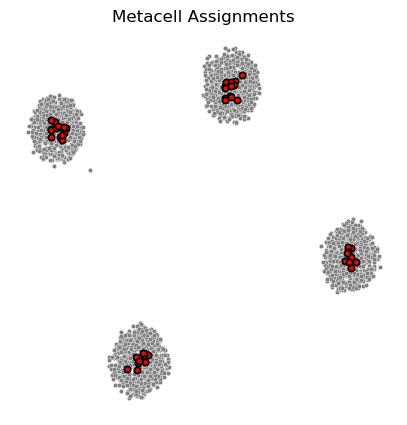

In [6]:
adata = sc.read_h5ad("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/preprocessed/batch.facLoc0.6_de.facLoc0.3_nbatch4_ngroup4_groupCells600_dropout.mid1.5_Batch3_preprocessed.h5ad")
adata.obs.head()
assigned_seacells = pd.read_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/seacell/batch.facLoc0.6_de.facLoc0.3_nbatch4_ngroup4_groupCells600_dropout.mid1.5_Batch3_hard_assignments.tsv", sep = "\t")
assigned_seacells
adata.obs["SEACell"] = assigned_seacells["SEACell"].values
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)
SEACells.plot.plot_2D(adata, key='X_umap', colour_metacells=False)


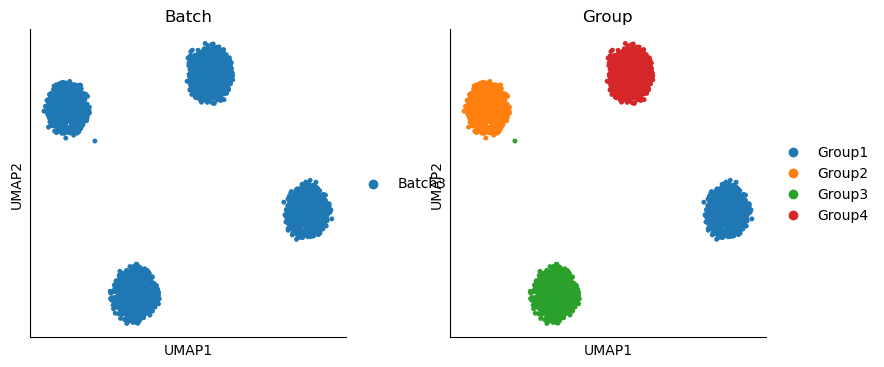

In [7]:

sc.pl.umap(adata, color=["Batch","Group"])

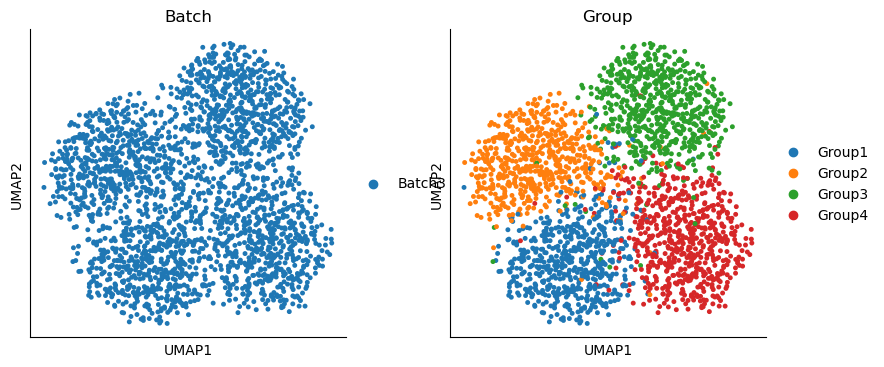

In [8]:
test = ad.AnnData(adata.raw.X, obs=adata.obs, var=adata.raw.var)
sc.pp.normalize_total(test, target_sum=10e4) # we temporarily normalize the .X because we need it for detecting the highly variable genes but after that we delete it
sc.pp.log1p(test)
sc.pp.highly_variable_genes(test, n_top_genes=2000)
sc.tl.pca(test, svd_solver='arpack')
sc.pp.neighbors(test, n_neighbors=10, n_pcs=50)
sc.tl.umap(test)

sc.pl.umap(test, color=["Batch","Group"])

# merge the seacell batches together to their parent samples again
* I want to process them using the integration pipeline again

In [9]:
out_seacell_concat_dir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged"
in_seacell_dir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/seacell/"
for p_sample in samplesheet_seacells.parent_sample.unique():
    sub_df = samplesheet_seacells[samplesheet_seacells["parent_sample"] == p_sample]
    adata_list = []
    outfile = join(out_seacell_concat_dir, f"{p_sample}_merged_seacell.h5ad")
    if os.path.exists(outfile):
        print(f"{p_sample}_merged_seacell.h5ad already exists in \n{out_seacell_concat_dir}")
        continue
    else:
        for ind, row in sub_df.iterrows():
            adata_path = join(in_seacell_dir, f"{row.sample_name}_summarised_seacell.h5ad")
            batch = row.Batch
            adata = sc.read_h5ad(adata_path)
            adata.obs["Batch"] = batch
            # Rename cell indices with the batch prefix
            adata.obs_names = [f"{batch}_{cell}" for cell in adata.obs_names]
            adata_list.append(adata)
        adata = ad.concat(adata_list, 
                          join='outer')
        adata.write_h5ad(outfile)
        print(f"Saved {p_sample}_merged_seacell.h5ad in \n{out_seacell_concat_dir}")



batch.facLoc0_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5_merged_seacell.h5ad already exists in 
/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged
batch.facLoc0.001_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5_merged_seacell.h5ad already exists in 
/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged
batch.facLoc0.01_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5_merged_seacell.h5ad already exists in 
/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged
batch.facLoc0.05_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5_merged_seacell.h5ad already exists in 
/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged
batch.facLoc0.1_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5_merged_seacell.h5ad already exists

# determine cell type purity to have some sort of annotation for the SEACells
* If the low biological variability samples prove to be too difficult, only consider the high biological variability samples.
## Idea: plot the median cell type purity per sample and make a cutoff per sample
* only keep samples that have median celltype purity >= 80/90 % ==> that way, I make sure keep at least half of the SEACells cells of that sample...
* Then I want to have SEACells with celltype purity > 80/90 %
* is this reasonable?


In [10]:
def get_obs_data(h5ad_file_path):
    adata = ad.read_h5ad(h5ad_file_path, backed='r')
    obs_df = adata.obs.copy()
    adata.file.close()
    return obs_df
def calc_celltype_purity(obs_df):
    obs_df = obs_df.copy()
    
    def purity_func(group):
        # Get the counts of each Group in the SEACell
        counts = group['Group'].value_counts()
        # Identify the most common Group and its count
        most_common_group = counts.idxmax()
        most_common_count = counts.max()
        # Total number of cells in the SEACell
        total_count = counts.sum()
        # Calculate purity
        purity = most_common_count / total_count
        return pd.Series({'Group': most_common_group, 'celltype_purity': purity})
    
    # Apply the function to each SEACell group
    result = obs_df.groupby('SEACell').apply(purity_func)
    result['batch'] = obs_df['Batch'].unique()[0]
    result.reset_index(inplace=True, names = 'SEACell')
    return result

def get_median_purity(h5ad_file_path):
    obs = get_obs_data(h5ad_file_path)
    purity = calc_celltype_purity(obs)
    median_purity = purity["celltype_purity"].median()
    return median_purity

def process_group(group):
    # group is a subset of the original df for one parent_sample
    # It contains multiple h5ad file paths.
    purities = []
    for file_path in group['preprocessed_path']:
        obs_df = get_obs_data(file_path)
        purity_df = calc_celltype_purity(obs_df)
        purities.append(purity_df['celltype_purity'])

    # Combine all purities from this parent_sample
    all_purities = pd.concat(purities, ignore_index=True)
    median_purity = all_purities.median()  # or mean, if you prefer

    # Return a Series with just the median purity
    return pd.Series({'median_purity': median_purity})

In [26]:
in_seacell_dir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/seacell/"
preprocessed_dir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/preprocessed/"
samplesheet_seacells["preprocessed_path"] = samplesheet_seacells.sample_name.apply(lambda x: join(preprocessed_dir, f"{x}_preprocessed.h5ad"))
samplesheet_seacells["seacell_path"] = samplesheet_seacells.sample_name.apply(lambda x: join(in_seacell_dir, f"{x}_summarised_seacell.h5ad"))
samplesheet_seacells["assignments"] = samplesheet_seacells.sample_name.apply(lambda x: join(in_seacell_dir, f"{x}_hard_assignments.tsv"))

In [23]:
if os.path.exists("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/preprocessed/purity_df.csv"):
    print("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/preprocessed/purity_df.csv already exists")
    print("loading purity_df")
    purity_df = pd.read_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/preprocessed/purity_df.csv")
else:
    samplesheet_seacells["median_purity"] = samplesheet_seacells.preprocessed_path.apply(get_median_purity)
    purity_df = samplesheet_seacells.groupby('parent_sample').apply(process_group).reset_index()
    purity_df.to_csv(
        "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/preprocessed/purity_df.csv", 
        index = False
        )
purity_df.head()



/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/preprocessed/purity_df.csv already exists
loading purity_df


,parent_sample,median_purity
0,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.341186
1,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.325834
2,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.343304
3,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.333333
4,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.333333


In [24]:
purity_df = purity_df.merge(samplesheet_seacells.loc[:,["parent_sample", "batch.facLoc", "de.facLoc", "dropout.mid"]].drop_duplicates(), on = "parent_sample")
purity_df.head()

,parent_sample,median_purity,batch.facLoc,de.facLoc,dropout.mid
0,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.341186,0.001,0.001,0.5
1,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.325834,0.001,0.001,1.0
2,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.343304,0.001,0.001,1.5
3,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.333333,0.001,0.001,2.0
4,batch.facLoc0.001_de.facLoc0.001_nbatch4_ngrou...,0.333333,0.001,0.001,2.5


<Axes: xlabel='dropout.mid', ylabel='median_purity'>

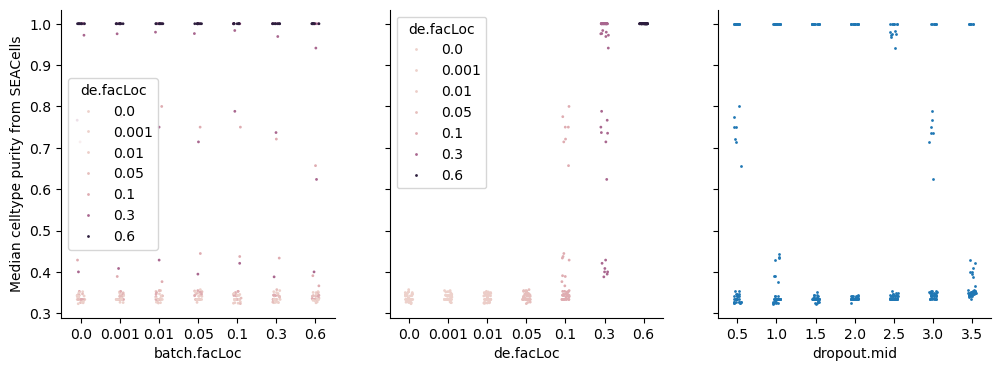

In [14]:
a4_dims = (12, 4)
fig, ax = plt.subplots(1,3,figsize=a4_dims, sharey=True)
ax[0].set_ylabel("Median celltype purity from SEACells")

sns.stripplot(
    data = purity_df,
    x = "batch.facLoc",
    y = "median_purity",
    hue = "de.facLoc",
    ax = ax[0],
    size = 2,
    legend = 'full'
)

sns.stripplot(
    data = purity_df,
    x = "de.facLoc",
    y = "median_purity",
    hue = "de.facLoc",
    ax = ax[1],
    size = 2,
    legend = 'full'
)

sns.stripplot(
    data = purity_df,
    x = "dropout.mid",
    y = "median_purity",
    ax = ax[2],
    size = 2,
    legend = 'full'
)


In [15]:
import statsmodels.formula.api as smf
fit_df = purity_df.copy()
fit_df.columns = fit_df.columns.str.replace('.', '_', regex=False)
model = smf.ols(formula='median_purity ~ batch_facLoc * de_facLoc + dropout_mid', data=fit_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          median_purity   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     414.9
Date:                Thu, 19 Dec 2024   Prob (F-statistic):          5.63e-129
Time:                        08:55:17   Log-Likelihood:                 249.93
No. Observations:                 343   AIC:                            -489.9
Df Residuals:                     338   BIC:                            -470.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

In [16]:
purity_df.shape

(343, 5)

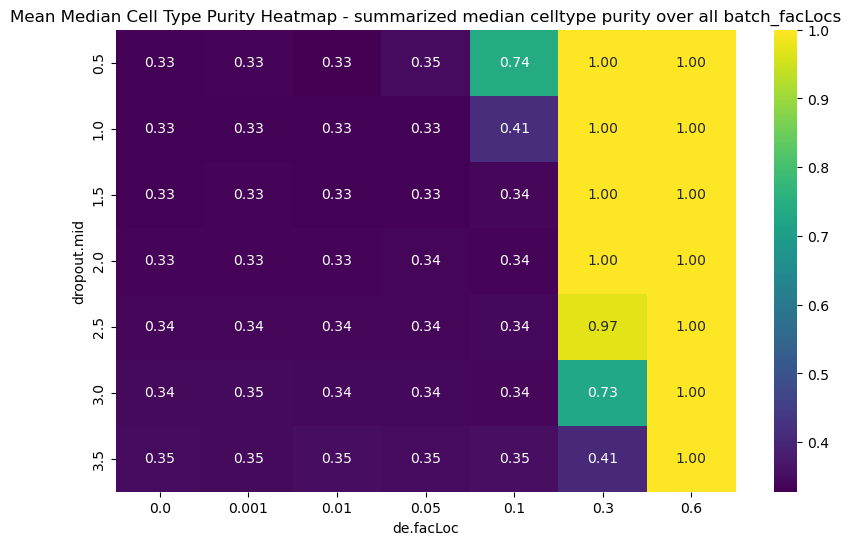

In [17]:
pivot_table = purity_df.loc[:, ['batch.facLoc', 'de.facLoc', 'median_purity','dropout.mid']].groupby(['dropout.mid', 'de.facLoc']).agg(mean_median_purity=('median_purity', 'mean')).reset_index()
pivot_table = pivot_table.pivot(index='dropout.mid', columns='de.facLoc', values='mean_median_purity')
pivot_table.head()
# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="viridis")
plt.title("Mean Median Cell Type Purity Heatmap - summarized median celltype purity over all batch_facLocs")
plt.ylabel("dropout.mid")
plt.xlabel("de.facLoc")
plt.show()


## it looks like the cell type purity is strongly dependent on the biological variability of the sample as expected..
* SEACells cannot tell apart the celltype/group labels generated by splatter because there are basically no differences between the groups.
* However, we need celltype/groups annotation in order to quantify the quality of the integrations later on.
    * Therefore, we restrict the benchmarking to the samples that have median 80 % celltype purity and then only use the SEACells that have 90 % celltype purity for the benchmarking
    

In [18]:
# test = sc.read_h5ad()
out_seacell_concat_dir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged"
files = [join(out_seacell_concat_dir, file) for file in os.listdir(out_seacell_concat_dir) if file.endswith(".h5ad")]
test = sc.read_h5ad(files[0])
# samplesheet_seacells.head()
test.obs.head()

,Batch
Batch1_SEACell-14,Batch1
Batch1_SEACell-18,Batch1
Batch1_SEACell-33,Batch1
Batch1_SEACell-20,Batch1
Batch1_SEACell-3,Batch1


In [20]:
samplesheet_seacells.parent_sample[0]

'batch.facLoc0_de.facLoc0_nbatch4_ngroup4_groupCells600_dropout.mid0.5'

In [27]:
filtered_df = purity_df[purity_df['median_purity'] > 0.8].reset_index(drop=True).copy()
filtered_df['remerged_path'] = filtered_df['parent_sample'].apply(lambda x: join(out_seacell_concat_dir, x + "_merged_seacell.h5ad"))
filtered_df = samplesheet_seacells.merge(filtered_df.loc[:, ['parent_sample','remerged_path']], how = 'inner')
filtered_df


,sample_name,file_path,parent_sample,original_h5ad,batch.facLoc,de.facLoc,nbatch,ngroup,groupCells,dropout.mid,Batch,preprocessed_path,assigments,median_purity,seacell_path,assignments,remerged_path
0,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.3,4,4,600,0.5,Batch1,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,1.0,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...
1,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.3,4,4,600,0.5,Batch2,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,1.0,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...
2,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.3,4,4,600,0.5,Batch3,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,1.0,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...
3,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_gro...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.000,0.3,4,4,600,0.5,Batch4,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,1.0,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...
4,batch.facLoc0.001_de.facLoc0.3_nbatch4_ngroup4...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0.001_de.facLoc0.3_nbatch4_ngroup4...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.001,0.3,4,4,600,0.5,Batch1,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,1.0,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,batch.facLoc0.3_de.facLoc0.6_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0.3_de.facLoc0.6_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.300,0.6,4,4,600,3.5,Batch4,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,1.0,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...
332,batch.facLoc0.6_de.facLoc0.6_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0.6_de.facLoc0.6_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.600,0.6,4,4,600,3.5,Batch1,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,1.0,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...
333,batch.facLoc0.6_de.facLoc0.6_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,batch.facLoc0.6_de.facLoc0.6_nbatch4_ngroup4_g...,/local/Projects/AAkalin_Neuroblastoma/Results/...,0.600,0.6,4,4,600,3.5,Batch2,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/.

In [28]:
filtered_df.columns

Index(['sample_name', 'file_path', 'parent_sample', 'original_h5ad',
       'batch.facLoc', 'de.facLoc', 'nbatch', 'ngroup', 'groupCells',
       'dropout.mid', 'Batch', 'preprocessed_path', 'assigments',
       'median_purity', 'seacell_path', 'assignments', 'remerged_path'],
      dtype='object')

In [30]:
test = get_obs_data(filtered_df.seacell_path[0])
test.head()

""
SEACell-33
SEACell-1
SEACell-36
SEACell-11
SEACell-13


In [40]:
for i in range(0,5):
    print(filtered_df.parent_sample[i])

batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_groupCells600_dropout.mid0.5
batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_groupCells600_dropout.mid0.5
batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_groupCells600_dropout.mid0.5
batch.facLoc0_de.facLoc0.3_nbatch4_ngroup4_groupCells600_dropout.mid0.5
batch.facLoc0.001_de.facLoc0.3_nbatch4_ngroup4_groupCells600_dropout.mid0.5


In [ ]:
out_filtered = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged/filtered"
filtered_df.head()
for p_sample in filtered_df.parent_sample.unique():
    sub_df = filtered_df.loc[filtered_df.parent_sample == p_sample]
    outfile = join(out_filtered, f"{p_sample}_filtered.h5ad")
    batch_list = []
    sum_cells = []
    print(f"processing {p_sample}")
    if os.path.exists(outfile):
        print(f"{outfile} already exists. Skipping...")
    else:
        print("loading batches, calculating cell type purity and filter SEACells")
        for ind, row in sub_df.iterrows():
            obs = get_obs_data(row.preprocessed_path)
            purity = calc_celltype_purity(obs)
            purity.set_index("SEACell", inplace = True)
            seacell_batch_adata = sc.read_h5ad(row.seacell_path)
            sum_cells.append(seacell_batch_adata.n_obs)
            seacell_batch_adata.obs = seacell_batch_adata.obs.join(purity)
            # print(seacell_batch_adata.obs.head())
            seacell_batch_adata = seacell_batch_adata[seacell_batch_adata.obs["celltype_purity"] >= 0.8]
            seacell_batch_adata.obs["Batch"] = row.Batch
            # Rename cell indices with the batch prefix
            seacell_batch_adata.obs_names = [f"{row.Batch}_{cell}" for cell in seacell_batch_adata.obs_names]
            batch_list.append(seacell_batch_adata)
        print(f"initial number of cells: {sum(sum_cells)}\n number of filtered cells: {sum([x.n_obs for x in batch_list])}")
        filtered_merged_adata = ad.concat(batch_list)
        print(f"saving {outfile}")
        filtered_merged_adata.write_h5ad(outfile)

## write samplesheet for filtered, merged, and annotated SEACell data

In [74]:
def make_samplesheet(dir):
    files = os.listdir(dir)
    files = [file for file in files if file.endswith(".h5ad") or file.endswith(".h5") or file.endswith(".hdf5")]
    file_paths = [os.path.join(dir, file) for file in files] #[os.path.abspath(
    file_paths = [os.path.abspath(file) for file in file_paths]
    sample_name = [file.split(".h5ad")[0] for file in files]
    df = pd.DataFrame({"sample_name": sample_name, "file_path": file_paths})
    return df
samplesheet_filtered = make_samplesheet(out_filtered)
samplesheet_filtered['parent_sample'] = samplesheet_filtered['sample_name'].apply(lambda x: x.split("_filtered")[0])
samplesheet_filtered = samplesheet_filtered.merge(filtered_df.loc[:, ['parent_sample', 'batch.facLoc','de.facLoc','dropout.mid']].drop_duplicates())
samplesheet_filtered['parent_sample'] = samplesheet_filtered['sample_name']
samplesheet_filtered.to_csv(
    "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/own_sim/SEACells/re_merged/filtered/samplesheet.tsv",
    sep = "\t",
    index = False)
